In [2]:
import os
import mlflow
import pandas as pd
import matplotlib.pyplot as plt

MLFLOW_URI = os.environ.get("MLFLOW_TRACKING_URI", "http://mlflow:5000")
mlflow.set_tracking_uri(MLFLOW_URI)

EXPERIMENT = "sentiment_analysis"
METRICS = [
    "test_f1_macro",
    "test_f1_weighted",
    "test_accuracy",
    "test_precision",
    "test_recall",
]


def load_group(tag_key):
    runs = mlflow.search_runs(
        experiment_names=[EXPERIMENT],
        filter_string=f"tags.`{tag_key}` != ''",
        order_by=["metrics.test_f1_macro DESC"],
    )
    cols = [f"tags.{tag_key}"] + [
        f"metrics.{m}" for m in METRICS if f"metrics.{m}" in runs.columns
    ]
    df = runs[cols].rename(columns={f"tags.{tag_key}": tag_key})
    df.columns = [c.replace("metrics.", "") for c in df.columns]
    return df.reset_index(drop=True)


def bar_chart(df, group_col, metric="test_f1_macro", title=""):
    n = len(df)
    fig, ax = plt.subplots(figsize=(max(6, n * 1.4), 4))
    bars = ax.bar(range(n), df[metric], color="steelblue", width=0.6)
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
    ax.set_xticks(range(n))
    ax.set_xticklabels(df[group_col], rotation=45, ha="right", fontsize=9)
    ax.set_ylim(df[metric].min() * 0.97, df[metric].max() * 1.02)
    ax.set_ylabel("F1-macro (test)")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## 1. Comparison of Numerical Feature Scaling Methods

,scalers_comparison,test_f1_macro,test_f1_weighted,test_accuracy,test_precision,test_recall
0,robust,0.865,0.917,0.9137,0.8409,0.898
1,standard,0.865,0.917,0.9137,0.8409,0.898
2,minmax,0.865,0.917,0.9137,0.8409,0.898


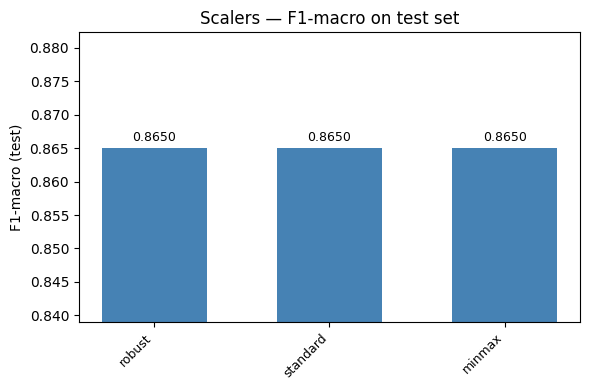

In [3]:
scalers = load_group("scalers_comparison")
display(scalers)
bar_chart(scalers, "scalers_comparison", title="Scalers — F1-macro on test set")

We can see that the choice of scaler has no impact on the model’s performance. MinMax, Standard, and Robust scalers all produce the same results. This is likely because numerical features are not crucial for this task. The best option for us is the MinMax scaler, as it does not introduce negative values, which later interfere with feature selection.

## 2. Comparison of Text Vectorization Methods

,vectorizer_comparison,test_f1_macro,test_f1_weighted,test_accuracy,test_precision,test_recall
0,tfidf,0.8650,0.9170,0.9137,0.8409,0.8980
1,bow,0.8547,0.9113,0.9083,0.8341,0.8818
2,word2vec,0.7710,0.8499,0.8370,0.7439,0.8374


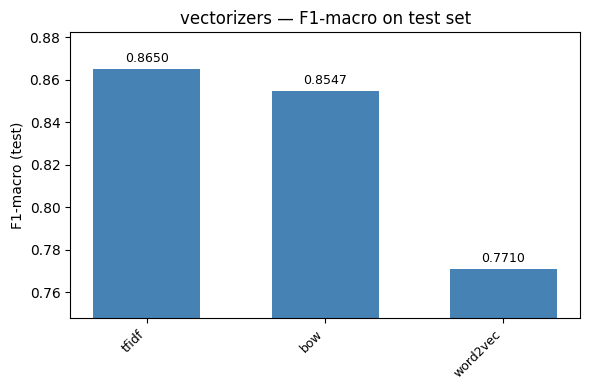

In [4]:
vectorizers = load_group("vectorizer_comparison")
display(vectorizers)
bar_chart(
    vectorizers, "vectorizer_comparison", title="vectorizers — F1-macro on test set"
)

The best text vectorization method turned out to be TF-IDF, which performs slightly better than Bag-of-Words, while Word2Vec performs significantly worse. This may be because we are using a pre-trained Word2Vec model that is not tailored to our specific task. Additionally, Word2Vec uses only 300 features, whereas BoW and TF-IDF use up to 5000, which may also contribute to the performance difference.


## 3. Comparison of Feature Selection Methods

,method,n_top_features,n_components,test_f1_macro,test_f1_weighted,test_accuracy,test_precision,test_recall
0,select_k_best,5000,100,0.8670,0.9179,0.9143,0.8411,0.9038
1,select_k_best,15000,100,0.8666,0.9179,0.9146,0.8421,0.9005
2,select_k_best,30000,100,0.8650,0.9170,0.9137,0.8409,0.8980
3,none,5000,100,0.8650,0.9170,0.9137,0.8409,0.8980
4,truncated_svd,5000,300,0.8267,0.8897,0.8823,0.7962,0.8820
5,both,30000,200,0.8011,0.8710,0.8608,0.7710,0.8657
6,truncated_svd,5000,200,0.8011,0.8710,0.8608,0.7710,0.8657
7,both,20000,100,0.7523,0.8338,0.8174,0.7279,0.8304
8,truncated_svd,5000,100,0.7441,0.8274,0.8099,0.7210,0.8234


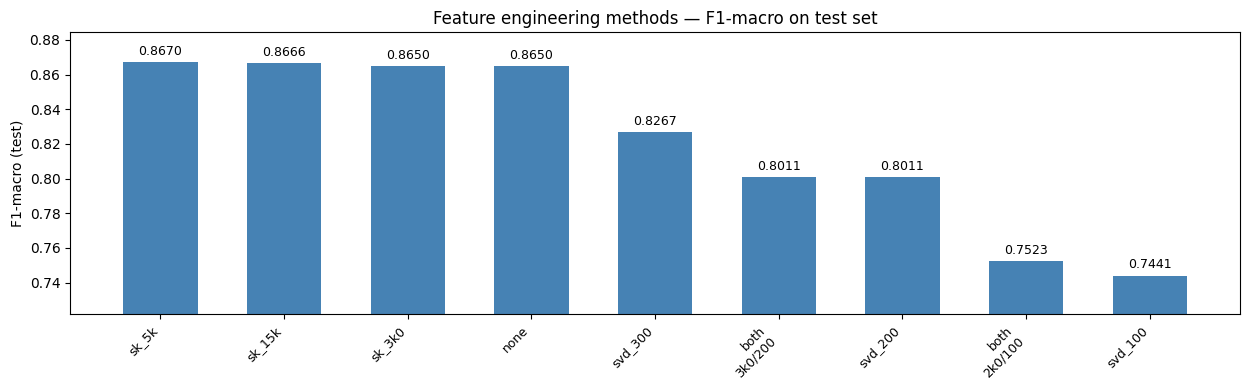

In [5]:
runs_fe = mlflow.search_runs(
    experiment_names=[EXPERIMENT],
    filter_string="tags.`feature_engineering` != ''",
    order_by=["metrics.test_f1_macro DESC"],
)

fe_cols = {
    "tags.feature_engineering": "method",
    "params.n_top_features": "n_top_features",
    "params.n_components": "n_components",
    **{f"metrics.{m}": m for m in METRICS},
}
features = runs_fe[[c for c in fe_cols if c in runs_fe.columns]].rename(columns=fe_cols)


def make_label(row):
    m = row["method"]
    k = str(row.get("n_top_features", "?"))
    n = str(row.get("n_components", "?"))
    k_short = k.replace("000", "k") if k != "?" else "?"
    if m == "select_k_best":
        return f"sk_{k_short}"
    if m == "truncated_svd":
        return f"svd_{n}"
    if m == "both":
        return f"both\n{k_short}/{n}"
    return m


features["config"] = features.apply(make_label, axis=1)
display(features.drop(columns=["config"]))
bar_chart(
    features, "config", title="Feature engineering methods — F1-macro on test set"
)

The best result was achieved with aggressive feature selection using SelectKBest with k=5000 (F1-macro = 0.867), slightly outperforming no feature selection (0.865). Increasing k further does not improve performance, suggesting that most of the sentiment signal is concentrated in a relatively small subset of words. TruncatedSVD (LSA) significantly reduces performance (0.74–0.83), as compressing the data into a latent space removes information important for a linear classifier.


## 4. Final Model Performance

Final run: 35599961120648608332bbeb3f88648e


,test_f1_macro,test_f1_weighted,test_accuracy,test_precision,test_recall
0,0.8726,0.921,0.9172,0.8446,0.9134


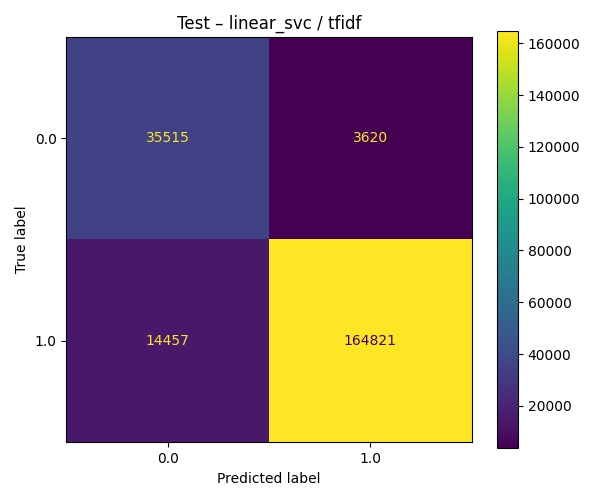

In [11]:
import tempfile, os
from IPython.display import Image, display as ipy_display

final_runs = mlflow.search_runs(
    experiment_names=[EXPERIMENT],
    filter_string="tags.`final` = 'selectk_5000'",
    order_by=["metrics.test_f1_macro DESC"],
)
final_run_id = final_runs.iloc[0]["run_id"]
print(f"Final run: {final_run_id}")

display(
    final_runs[["metrics." + m for m in METRICS]].rename(
        columns=lambda c: c.replace("metrics.", "")
    )
)

client = mlflow.MlflowClient()
with tempfile.TemporaryDirectory() as tmp:
    local_dir = client.download_artifacts(
        final_run_id, "confusion_matrices/confusion_matrix_test.png", tmp
    )
    ipy_display(Image(filename=local_dir))

The model trained on the full dataset (873k samples) achieved an F1-macro of 0.873 on the test set, improving over the model trained on 100k samples (0.867). The confusion matrix confirms strong performance — the model correctly classifies 35,515 negative and 164,821 positive reviews. The main source of errors remains false negatives (14,457), which is a natural consequence of the imbalanced dataset (82% positive class).